In [10]:
import pandas as pd
import numpy as np

df = pd.read_csv("student_data1.csv")
print("top row")
print(df.head())
print("shape")
print(f'row:{df.shape[0]},columns:{df.shape[1]}')
print("information")
print(df.info)
print("summary")
print(df.describe(include='all'))
print("missing value count")
print(df.isnull().sum())
print("data type")
print(df.dtypes)

top row
   studyhours  attendance  pastscore internet  sleephours passed
0           4          30         40      yes          10    yes
1           3          40         20       no           8    yes
2           4          40         60       no          15    yes
3           9          80         70      yes           3    yes
4           8          40         30       no          12     no
shape
row:19,columns:6
information
<bound method DataFrame.info of     studyhours  attendance  pastscore internet  sleephours passed
0            4          30         40      yes          10    yes
1            3          40         20       no           8    yes
2            4          40         60       no          15    yes
3            9          80         70      yes           3    yes
4            8          40         30       no          12     no
5            2          50         40      yes           8     no
6           10          80         90      yes          14    yes
7      

In [11]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("student_data1.csv")
print("missing value in column")
print(df.isnull().sum())
le = LabelEncoder()
df['internet']=le.fit_transform(df['internet'])
df['passed']=le.fit_transform(df['passed'])
print("after encoding")
print(df.head)
print("data type after cleaning")
print(df.dtypes)



missing value in column
studyhours    0
attendance    0
pastscore     0
internet      0
sleephours    0
passed        0
dtype: int64
after encoding
<bound method NDFrame.head of     studyhours  attendance  pastscore  internet  sleephours  passed
0            4          30         40         1          10       1
1            3          40         20         0           8       1
2            4          40         60         0          15       1
3            9          80         70         1           3       1
4            8          40         30         0          12       0
5            2          50         40         1           8       0
6           10          80         90         1          14       1
7            8          60         70         1           9       1
8            9          80         90         1           6       1
9           11          90        100         1           4       1
10           2          38         56         1           8       0
11    

Classification Report
              precision    recall  f1-score   support

           0       0.33      1.00      0.50         1
           1       1.00      0.33      0.50         3

    accuracy                           0.50         4
   macro avg       0.67      0.67      0.50         4
weighted avg       0.83      0.50      0.50         4



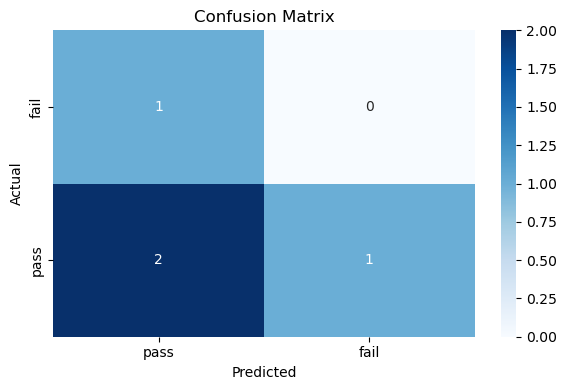

----predict your result----
prediction based on student result:Pass


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv("student_data1.csv")
le=LabelEncoder()
# df['internet']=le.fit_transform(df['internet'])
# df['passed']=le.fit_transform(df['passed'])
df['internet']=le.fit_transform(df['internet'])
df['passed']=le.fit_transform(df['passed'])

features=['studyhours','attendance','pastscore','internet','sleephours']
scaler=StandardScaler()
df_scaler=df.copy()
df_scaler[features]=scaler.fit_transform(df_scaler[features])

X=df_scaler[features] # features
y=df_scaler['passed'] # terget

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

model=LogisticRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

print("Classification Report")
print(classification_report(y_test,y_pred))
con_matrix=confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(
    con_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["pass", "fail"],
    yticklabels=["fail", "pass"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

print("----predict your result----")
try: 
    studyhours=float(input("enter study Hours:")) 
    attendance=float(input("enter attendance:")) 
    pastscore=float(input("enter pastscore:")) 
    internet=input("enter use internet(yes/no):").strip().lower() 
    sleephours=float(input("enter sleephours:"))
    # passed=input("enter passed(yes/no):")
    
    internet = 1 if internet == "yes" else 0
    user_input_df=pd.DataFrame([{'studyhours':studyhours, 
                                 'attendance':attendance, 
                                 'pastscore':pastscore, 
                                 'internet':internet, 
                                 'sleephours':sleephours
                                }])
    user_input_scaler=scaler.transform(user_input_df)
    user_input_scaler = pd.DataFrame(user_input_scaler, columns=features)
    prediction=model.predict(user_input_scaler)[0] 
    result="Pass"if prediction==1 else "Fail" 
    print(f"prediction based on student result:{result}")
except Exception as e: 
    print("an errer occured",e) 